# NBA Prediction Market Bias: Does Pre-Game Media Coverage Skew Market Prices?

**ICS 604: Applied Data Science — Final Project**  
**Author:** Nicholas Fairhart

---

## Research Question

Do NBA prediction markets exhibit systematic pricing bias correlated with pre-game media attention disparities?

## Formal Hypotheses

- **H₀ (Null):** Pre-game media coverage disparity has no effect on Kalshi market-implied probabilities — the losing team's overpricing is unrelated to how much media attention it received relative to the winning team.
- **H₁ (Alternative):** Teams receiving disproportionately more pre-game media coverage are systematically overpriced in prediction markets. The probability the market assigns to the eventual loser is higher when the loser had greater media coverage, independent of objective team quality.

## Analytical Plan

1. Data preprocessing & merging (three sources)
2. Exploratory data analysis
3. Hypothesis testing: bootstrap CI, permutation test, Welch t-test
4. Regression: OLS (bounded-variable check) + logistic regression on binary game outcome
5. Conclusions

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.formula.api as smf

np.random.seed(42)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

## Section 0: Data Preprocessing & Merging

Three datasets are combined:

| Source | File | Contents |
|--------|------|----------|
| Kalshi + GDELT (pre-aggregated) | `gdelt_nba_games.csv` | 1,339 games; market-implied probabilities, pre-game article counts, media disparity metrics |
| Pregame rolling team features | `nba_pregame_features.csv` | One row per game; trailing team form features (`t1_`, `t2_`) and differentials (`diff_`) built pre-tipoff |
| GDELT raw per-team | `gdelt_nba_coverage.csv` | One row per team-game; article count and sentiment — used to validate the aggregation in `gdelt_nba_games.csv` |

**GDELT preprocessing note:** The raw `gdelt_nba_coverage.csv` contains one row per team per game window. Duplicate article entries (same URL captured multiple times) were identified and dropped before aggregation. Article counts were summed and sentiment scores were averaged per team-game to produce the per-game metrics in `gdelt_nba_games.csv`.

**Merge strategy:** `nba_pregame_features.csv` is joined to each game row by `event_ticker`. This replaces the Basketball-Reference Net Rating controls with pregame rolling form controls learned in class-style regression workflows.

In [ ]:
# Load the three data sources
games_df = pd.read_csv('data/gdelt_nba_games.csv', parse_dates=['game_date'])
pregame_df = pd.read_csv('data/nba_pregame_features.csv', parse_dates=['game_date'])
coverage_df = pd.read_csv('data/gdelt_nba_coverage.csv')

print('gdelt_nba_games.csv:       ', games_df.shape)
print('nba_pregame_features.csv:  ', pregame_df.shape)
print('gdelt_nba_coverage.csv:    ', coverage_df.shape)
print()
print('Games date range:', games_df['game_date'].min().date(), '→', games_df['game_date'].max().date())

In [27]:
# --- Step 1: Join pregame rolling features onto each game row (ICS 604 style: merge + feature engineering) ---
merge_cols = [
    'event_ticker', 'diff_roll_win_pct', 'diff_roll_pm', 'diff_rest_days',
    't1_roll_win_pct', 't2_roll_win_pct', 'team1_won'
]

pregame_merge = pregame_df[merge_cols].copy()
games_df = games_df.merge(pregame_merge, on='event_ticker', how='left', suffixes=('', '_pregame'))

print('After pregame-feature join:')
print('  diff_roll_win_pct null count:', games_df['diff_roll_win_pct'].isnull().sum())
print('  diff_roll_pm      null count:', games_df['diff_roll_pm'].isnull().sum())

# --- Step 2: Derive analysis columns ---
# team1 = away team, team2 = home team (encoded in Kalshi ticker)
# winner_is_home: 1 if the home team (team2) won
games_df['winner_is_home'] = (games_df['winner'] == games_df['team2']).astype(int)

# media_disparity_loser: positive = losing team had MORE pre-game coverage
# media_disparity_t1 is positive when team1 has more articles
games_df['media_disparity_loser'] = np.where(
    games_df['winner'] == games_df['team1'],
    -games_df['media_disparity_t1'],   # team1 won -> loser is team2 -> flip sign
    games_df['media_disparity_t1']     # team2 won -> loser is team1 -> keep sign
)

# team1_won and team1_implied_prob (for logistic regression)
games_df['team1_won'] = (games_df['winner'] == games_df['team1']).astype(int)
games_df['team1_implied_prob'] = np.where(
    games_df['team1_won'] == 1,
    games_df['winner_implied_prob'],
    games_df['loser_implied_prob']
)

# Convert team1 differential features into winner-advantage controls for OLS
# Positive values mean the eventual winner had stronger pregame form.
games_df['pregame_adv_roll_win_pct'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_win_pct'],
    -games_df['diff_roll_win_pct']
)
games_df['pregame_adv_roll_pm'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_pm'],
    -games_df['diff_roll_pm']
)
games_df['pregame_adv_rest_days'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_rest_days'],
    -games_df['diff_rest_days']
)

# --- Step 3: GDELT minimum-coverage filter ---
# Teams with very sparse mentions (<10 articles) produce unstable disparity scores
min_articles = 10
nb_before_filter = len(games_df)
games_df = games_df[
    (games_df['team1_articles'] >= min_articles) &
    (games_df['team2_articles'] >= min_articles)
].copy()
print(f'Rows before coverage filter: {nb_before_filter:,}')
print(f'Rows after coverage filter:  {len(games_df):,}')

# --- Step 4: Drop rows with any remaining nulls in analysis columns ---
analysis_cols = [
    'loser_implied_prob', 'media_disparity_loser', 'winner_is_home',
    'pregame_adv_roll_win_pct', 'pregame_adv_roll_pm',
    'team1_won', 'team1_implied_prob', 'diff_roll_win_pct', 'diff_roll_pm', 'diff_rest_days'
]
nb_before_drop = len(games_df)
dfa = games_df.dropna(subset=analysis_cols).copy()
print(f'Rows after dropping nulls:   {len(dfa):,}  (dropped {nb_before_drop - len(dfa)})')

After pregame-feature join:
  diff_roll_win_pct null count: 193
  diff_roll_pm      null count: 193
Rows before coverage filter: 1,339
Rows after coverage filter:  1,251
Rows after dropping nulls:   1,069  (dropped 182)


## Section 1: Descriptive Statistics

Before testing hypotheses, we examine the distributions of the key variables to understand the data structure.

In [28]:
eda_cols = [
    'loser_implied_prob', 'media_disparity_loser',
    'pregame_adv_roll_win_pct', 'pregame_adv_roll_pm',
    'team1_articles', 'team2_articles'
]
dfa[eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
loser_implied_prob,1069.0000,0.3955,0.2070,0.0218,0.2241,0.3663,0.5478,0.8998
media_disparity_loser,1069.0000,-0.0166,0.1316,-0.4157,-0.1031,-0.0174,0.0720,0.3636
pregame_adv_roll_win_pct,1069.0000,0.3495,0.9532,-2.5350,-0.3007,0.3007,0.9761,3.2104
pregame_adv_roll_pm,1069.0000,0.3771,0.9472,-2.6516,-0.2711,0.3481,1.0855,3.0795
team1_articles,1069.0000,77.1506,34.0873,14.0000,54.0000,70.0000,91.0000,283.0000
team2_articles,1069.0000,74.7203,33.6671,16.0000,52.0000,68.0000,89.0000,295.0000


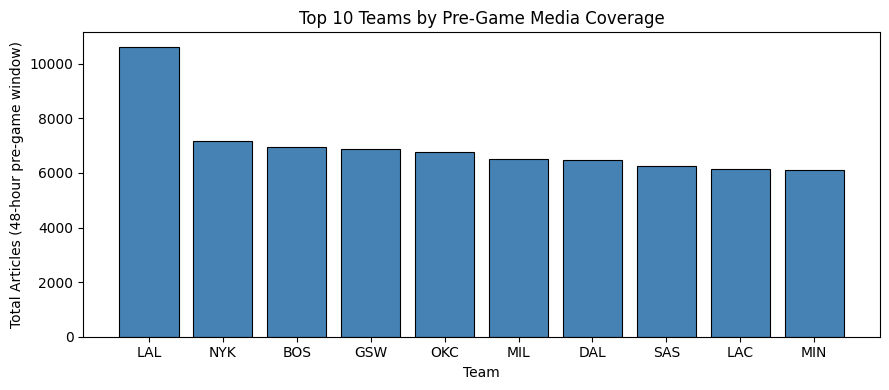

In [29]:
# Total article mentions per team across all games (team1 + team2 appearances)
team1_counts = dfa.groupby('team1')['team1_articles'].sum()
team2_counts = dfa.groupby('team2')['team2_articles'].sum()
total_coverage = (team1_counts.add(team2_counts, fill_value=0)
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(9, 4))
plt.bar(total_coverage.index, total_coverage.values, color='steelblue', edgecolor='black', linewidth=0.8)
plt.xlabel('Team')
plt.ylabel('Total Articles (48-hour pre-game window)')
plt.title('Top 10 Teams by Pre-Game Media Coverage')
plt.tight_layout()
plt.savefig('fig_coverage_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

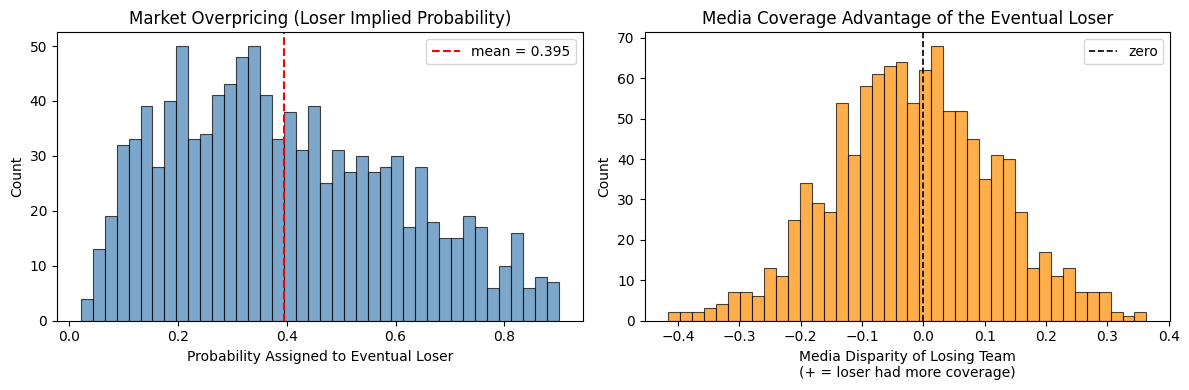

Loser had MORE pre-game coverage: 486 games (45.5%)


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loser implied probability distribution
axes[0].hist(dfa['loser_implied_prob'], bins=40, edgecolor='black', linewidth=0.8,
             alpha=0.7, color='steelblue')
axes[0].axvline(dfa['loser_implied_prob'].mean(), color='red', linestyle='--',
                label=f"mean = {dfa['loser_implied_prob'].mean():.3f}")
axes[0].set_xlabel('Probability Assigned to Eventual Loser')
axes[0].set_ylabel('Count')
axes[0].set_title('Market Overpricing (Loser Implied Probability)')
axes[0].legend()

# Media disparity of loser distribution
axes[1].hist(dfa['media_disparity_loser'], bins=40, edgecolor='black', linewidth=0.8,
             alpha=0.7, color='darkorange')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='zero')
axes[1].set_xlabel('Media Disparity of Losing Team\n(+ = loser had more coverage)')
axes[1].set_ylabel('Count')
axes[1].set_title('Media Coverage Advantage of the Eventual Loser')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Loser had MORE pre-game coverage: {(dfa['media_disparity_loser'] > 0).sum():,} games "
      f"({(dfa['media_disparity_loser'] > 0).mean()*100:.1f}%)")

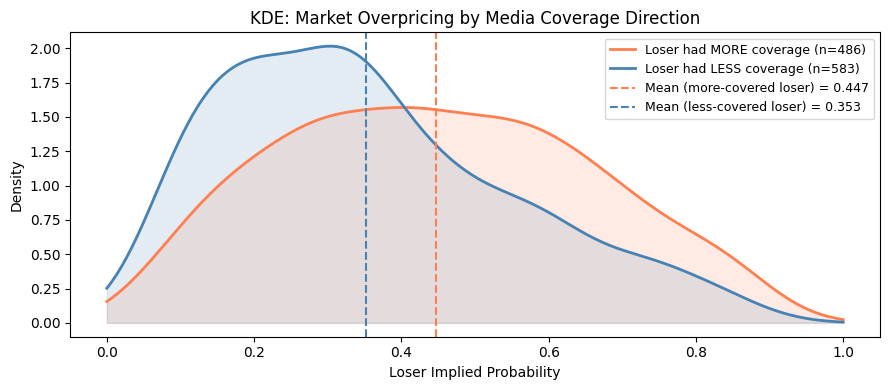

In [31]:
# Gaussian KDE: pricing-error distributions for high-coverage vs low-coverage losers
# Split on SIGNED disparity — positive = loser had more coverage, negative = loser had less
pos_group = dfa[dfa['media_disparity_loser'] > 0]['loser_implied_prob'].dropna()
neg_group = dfa[dfa['media_disparity_loser'] <= 0]['loser_implied_prob'].dropna()

kde_pos = scipy.stats.gaussian_kde(pos_group)
kde_neg = scipy.stats.gaussian_kde(neg_group)
x_vals = np.linspace(0, 1, 300)

plt.figure(figsize=(9, 4))
plt.plot(x_vals, kde_pos(x_vals), color='coral', linewidth=2, label=f'Loser had MORE coverage (n={len(pos_group):,})')
plt.plot(x_vals, kde_neg(x_vals), color='steelblue', linewidth=2, label=f'Loser had LESS coverage (n={len(neg_group):,})')
plt.fill_between(x_vals, kde_pos(x_vals), alpha=0.15, color='coral')
plt.fill_between(x_vals, kde_neg(x_vals), alpha=0.15, color='steelblue')
plt.axvline(pos_group.mean(), color='coral', linestyle='--', linewidth=1.5,
            label=f'Mean (more-covered loser) = {pos_group.mean():.3f}')
plt.axvline(neg_group.mean(), color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Mean (less-covered loser) = {neg_group.mean():.3f}')
plt.xlabel('Loser Implied Probability')
plt.ylabel('Density')
plt.title('KDE: Market Overpricing by Media Coverage Direction')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_sentiment_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Mean loser implied probability by media disparity tertile:
                   n  mean_implied_prob    std  median_implied_prob
disparity_level                                                    
Low              356             0.3283 0.1838               0.3044
Medium           356             0.4021 0.2090               0.3710
High             357             0.4557 0.2077               0.4421


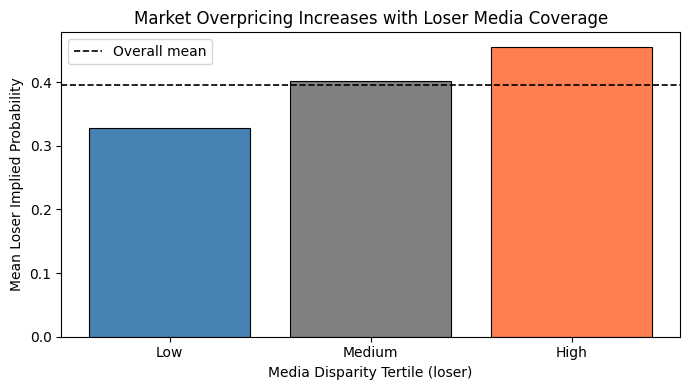

In [32]:
# Stratify by media disparity level (Low / Medium / High tertiles) using GroupBy
dfa['disparity_level'] = pd.qcut(dfa['media_disparity_loser'], q=3,
                                  labels=['Low', 'Medium', 'High'])

group_stats = (dfa.groupby('disparity_level', observed=True)['loser_implied_prob']
               .agg(['count', 'mean', 'std', 'median']))
group_stats.columns = ['n', 'mean_implied_prob', 'std', 'median_implied_prob']
print('Mean loser implied probability by media disparity tertile:')
print(group_stats.round(4))

plt.figure(figsize=(7, 4))
plt.bar(group_stats.index, group_stats['mean_implied_prob'],
        color=['steelblue', 'gray', 'coral'], edgecolor='black', linewidth=0.8)
plt.axhline(dfa['loser_implied_prob'].mean(), color='black', linestyle='--',
            linewidth=1.2, label='Overall mean')
plt.xlabel('Media Disparity Tertile (loser)')
plt.ylabel('Mean Loser Implied Probability')
plt.title('Market Overpricing Increases with Loser Media Coverage')
plt.legend()
plt.tight_layout()
plt.show()

## Section 2: Hypothesis Testing

**Grouping strategy:** We split games by the *sign* of `media_disparity_loser` rather than its absolute magnitude.

- **Group A** (`media_disparity_loser > 0`): loser had *more* pre-game coverage → market may have overpriced them
- **Group B** (`media_disparity_loser ≤ 0`): loser had *less* coverage → market less likely to overprice

Using absolute disparity (high vs. low) would mix the two directions and cause the effects to cancel — masking any real signal. The signed grouping preserves the directional structure of the hypothesis.

We apply three tests in parallel:
1. **Bootstrap confidence interval** — non-parametric estimate of mean difference
2. **Permutation test** — one-sided p-value with no distributional assumptions
3. **Welch t-test** — parametric test robust to unequal variance

In [35]:
pos_vals = dfa[dfa['media_disparity_loser'] > 0]['loser_implied_prob'].dropna().values
neg_vals = dfa[dfa['media_disparity_loser'] <= 0]['loser_implied_prob'].dropna().values

observed_diff = pos_vals.mean() - neg_vals.mean()

print(f'Group A — loser had MORE coverage: n={len(pos_vals):,}, mean={pos_vals.mean():.4f}')
print(f'Group B — loser had LESS coverage: n={len(neg_vals):,}, mean={neg_vals.mean():.4f}')
print(f'Observed mean difference (A − B):  {observed_diff:.4f}')

Group A — loser had MORE coverage: n=486, mean=0.4469
Group B — loser had LESS coverage: n=583, mean=0.3526
Observed mean difference (A − B):  0.0943


In [36]:
# Bootstrap confidence interval on the mean difference
nb_bootstrap_iters = 10_000
bootstrap_diffs = []

for i in range(nb_bootstrap_iters):
    boot_pos = np.random.choice(pos_vals, size=len(pos_vals), replace=True)
    boot_neg = np.random.choice(neg_vals, size=len(neg_vals), replace=True)
    bootstrap_diffs.append(boot_pos.mean() - boot_neg.mean())

ci = np.percentile(bootstrap_diffs, (2.5, 97.5))

print(f'Bootstrap 95% CI for mean difference: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'Zero is {"INSIDE" if ci[0] <= 0 <= ci[1] else "OUTSIDE"} the 95% CI')

Bootstrap 95% CI for mean difference: [0.0697, 0.1195]
Zero is OUTSIDE the 95% CI


In [37]:
# Permutation test (one-sided): H1 = Group A mean > Group B mean
nb_permutations = 10_000
combined = np.concatenate([pos_vals, neg_vals])
nb_pos = len(pos_vals)

perm_diffs = []
for i in range(nb_permutations):
    perm = np.random.permutation(combined)
    perm_diffs.append(perm[:nb_pos].mean() - perm[nb_pos:].mean())

p_val_permutation = np.mean(np.array(perm_diffs) >= observed_diff)

print(f'Permutation test (one-sided):')
print(f'  Observed difference:  {observed_diff:.4f}')
print(f'  p-value:              {p_val_permutation:.4f}')

Permutation test (one-sided):
  Observed difference:  0.0943
  p-value:              0.0000


In [95]:
# Welch t-test (does not assume equal variance)
result = scipy.stats.ttest_ind(pos_vals, neg_vals, equal_var=False)

print('Welch t-test:')
print(f'  statistic: {round(result.statistic, 4)}')
print(f'  pvalue:    {round(result.pvalue, 4)}')

Welch t-test:
  statistic: 7.5612
  pvalue:    0.0


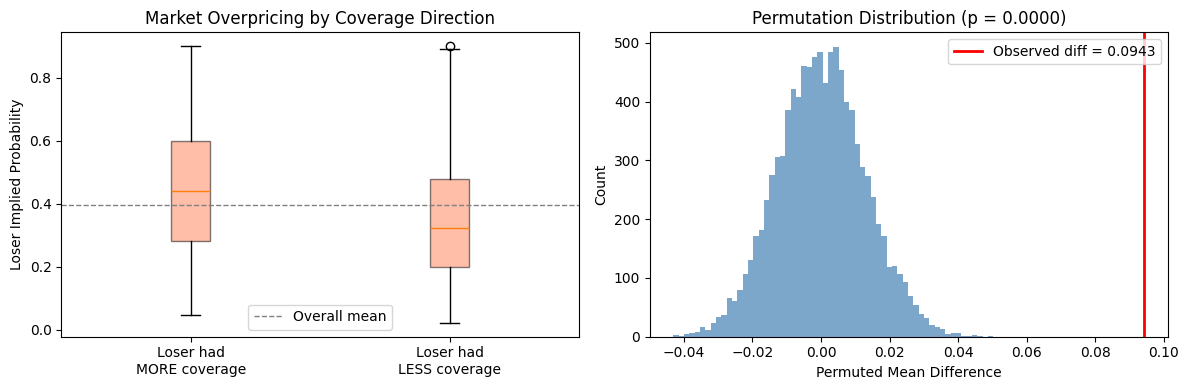

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot comparison
axes[0].boxplot([pos_vals, neg_vals], labels=['Loser had\nMORE coverage', 'Loser had\nLESS coverage'],
                patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[0].set_ylabel('Loser Implied Probability')
axes[0].set_title('Market Overpricing by Coverage Direction')
axes[0].axhline(dfa['loser_implied_prob'].mean(), color='gray', linestyle='--', linewidth=1,
                label='Overall mean')
axes[0].legend()

# Permutation distribution
axes[1].hist(perm_diffs, bins=60, edgecolor='none', alpha=0.7, color='steelblue')
axes[1].axvline(observed_diff, color='red', linewidth=2,
                label=f'Observed diff = {observed_diff:.4f}')
axes[1].set_xlabel('Permuted Mean Difference')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Permutation Distribution (p = {p_val_permutation:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_hypothesis_media.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Kalshi-Free Logistic Regression

**Goal:** Build a model that predicts game outcomes using only pregame statistics and media coverage — no Kalshi market prices. This produces a model-implied win probability that is independent of the market. Comparing it against Kalshi's implied probability then identifies potential mispricings.

**Pipeline:**

| Step | Purpose |
|------|---------|
| Feature inventory | Expand from 2 to all available pregame differentials + GDELT media features |
| Normalization | StandardScaler so coefficients are directly comparable across features |
| VIF check | Drop features with Variance Inflation Factor > 10 (multicollinearity) |
| Univariate screening | Fit each candidate individually; retain features with p < 0.10 |
| Model comparison | Baseline (pregame only) vs. Full (+media) — LRT, AUC, bootstrap CI |
| Mispricing analysis | `model_prob − Kalshi_implied_prob` as the gap signal |

### Step 1 — Feature Inventory, Normalization & VIF Check

We expand the merge to pull all 11 pregame differential columns plus `team1_home`, then add the 4 GDELT media features. All numeric features are standardized (mean = 0, std = 1) so coefficients will be on the same scale — a coefficient of 0.3 means the same thing whether it's for win rate or rebounds.

**Why standardize?**  
Raw differentials have very different units (win % is 0–1, plus-minus can be ±10). Without scaling, a large raw coefficient might just reflect a small unit, not a strong effect.

**VIF intuition:**  
If two features are near-perfectly correlated (e.g., `diff_roll_pts` and `diff_roll_pm` both measure scoring margin), their coefficients become unstable — the model can't tell which one is doing the work. VIF > 10 is the conventional cutoff for dropping a feature.

### Step 3 — Model Comparison: Baseline vs. Full (+Media)

Two nested logistic models, both Kalshi-free:

- **Baseline:** selected pregame features only
- **Full:** baseline + selected media features

The likelihood-ratio test (LRT) formally tests whether adding media features significantly improves fit. AUC and accuracy measure discriminative power.

In [97]:
nba_pregame_data = pregame_df.merge(games_df[['event_ticker', 'winner']], on='event_ticker', how='left')
nba_pregame_data.columns

Index(['event_ticker', 'game_date', 'team1', 'team2', 'winner_x', 'team1_home',
       'season', 'winner_implied_prob', 't1_roll_win_pct', 't1_roll_pts',
       't1_roll_opp_pts', 't1_roll_pm', 't1_roll_fg_pct', 't1_roll_fg3_pct',
       't1_roll_ft_pct', 't1_roll_reb', 't1_roll_ast', 't1_roll_tov',
       't1_roll_stl', 't1_roll_blk', 't1_rest_days', 't2_roll_win_pct',
       't2_roll_pts', 't2_roll_opp_pts', 't2_roll_pm', 't2_roll_fg_pct',
       't2_roll_fg3_pct', 't2_roll_ft_pct', 't2_roll_reb', 't2_roll_ast',
       't2_roll_tov', 't2_roll_stl', 't2_roll_blk', 't2_rest_days',
       'diff_roll_win_pct', 'diff_roll_pts', 'diff_roll_opp_pts',
       'diff_roll_pm', 'diff_roll_fg_pct', 'diff_roll_fg3_pct',
       'diff_roll_ft_pct', 'diff_roll_reb', 'diff_roll_ast', 'diff_roll_tov',
       'diff_roll_stl', 'diff_roll_blk', 'diff_rest_days', 'team1_won',
       'winner_y'],
      dtype='object')

In [98]:
#remove rows with nulls in the features or target
x_cols = ['diff_roll_win_pct', 'diff_roll_pts', 'diff_roll_opp_pts',
       'diff_roll_pm', 'diff_roll_fg_pct', 'diff_roll_fg3_pct',
       'diff_roll_ft_pct', 'diff_roll_reb', 'diff_roll_ast', 'diff_roll_tov',
       'diff_roll_stl', 'diff_roll_blk', 'diff_rest_days']
nba_pregame_data = nba_pregame_data.dropna(subset=(x_cols + ['team1_won']))

In [99]:
# Correlation-based feature selection
corr_with_outcome = nba_pregame_data[x_cols + ['team1_won']].corr()['team1_won'].drop('team1_won')
corr_with_outcome = corr_with_outcome.abs().sort_values(ascending=False)

print("=== Pearson |R| with team1_won ===")
print(corr_with_outcome.round(4).to_string())

selected_features = corr_with_outcome[corr_with_outcome > 0.05].index.tolist()
print(f"\nFeatures retained (|R| > 0.05): {selected_features}")

=== Pearson |R| with team1_won ===
diff_roll_pm        0.3661
diff_roll_opp_pts   0.3446
diff_roll_win_pct   0.3412
diff_roll_reb       0.1683
diff_roll_tov       0.1582
diff_roll_pts       0.1514
diff_roll_fg_pct    0.1482
diff_roll_blk       0.0913
diff_roll_fg3_pct   0.0799
diff_roll_ft_pct    0.0735
diff_roll_stl       0.0483
diff_roll_ast       0.0314
diff_rest_days      0.0204

Features retained (|R| > 0.05): ['diff_roll_pm', 'diff_roll_opp_pts', 'diff_roll_win_pct', 'diff_roll_reb', 'diff_roll_tov', 'diff_roll_pts', 'diff_roll_fg_pct', 'diff_roll_blk', 'diff_roll_fg3_pct', 'diff_roll_ft_pct']


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
base_model = LogisticRegression()
# x is difference in pregame features between team1 and team2, y is whether team1 won
X = nba_pregame_data[selected_features]
y = nba_pregame_data['team1_won']
X_scaled = scaler.fit_transform(X)

base_model.fit(X_scaled, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [101]:
#print feature importances by column name and absolute value of coefficients
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': base_model.coef_[0],
    'abs_coefficient': np.abs(base_model.coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)
print('Feature importances (by absolute coefficient value):')
print(coef_df[['feature', 'coefficient']])

Feature importances (by absolute coefficient value):
             feature  coefficient
1  diff_roll_opp_pts      -0.4137
0       diff_roll_pm       0.3431
2  diff_roll_win_pct       0.1559
4      diff_roll_tov      -0.1028
7      diff_roll_blk      -0.0630
8  diff_roll_fg3_pct      -0.0549
6   diff_roll_fg_pct       0.0509
3      diff_roll_reb       0.0413
5      diff_roll_pts       0.0273
9   diff_roll_ft_pct       0.0003


In [102]:
#add media disparity to the model and see if it has a significant coefficient
#first merge media disparity onto the pregame data
pregame_with_disparity = nba_pregame_data.merge(games_df[['event_ticker', 'media_disparity_loser']], on='event_ticker', how='left')
pregame_with_disparity = pregame_with_disparity.dropna(subset=(x_cols + ['team1_won', 'media_disparity_loser']))

#remove rows with nulls in the features or target
pregame_with_disparity.dropna(subset=(x_cols + ['team1_won', 'media_disparity_loser']), inplace=True)

#fit the model
X_disp = pregame_with_disparity[selected_features + ['media_disparity_loser']]
y_disp = pregame_with_disparity['team1_won']
X_disp_scaled = scaler.fit_transform(X_disp)
base_model.fit(X_disp_scaled, y_disp)


#now check the feature importance again and see if media disparity has a significant coefficient
coef_disp_df = pd.DataFrame({
    'feature': selected_features + ['media_disparity_loser'],
    'coefficient': base_model.coef_[0],
    'abs_coefficient': np.abs(base_model.coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)
print('\nFeature importances with media disparity included:')
print(coef_disp_df[['feature', 'coefficient']])


Feature importances with media disparity included:
                  feature  coefficient
1       diff_roll_opp_pts      -0.4438
0            diff_roll_pm       0.3591
10  media_disparity_loser      -0.1904
2       diff_roll_win_pct       0.1174
4           diff_roll_tov      -0.1084
7           diff_roll_blk      -0.0882
6        diff_roll_fg_pct       0.0654
3           diff_roll_reb       0.0517
5           diff_roll_pts       0.0164
9        diff_roll_ft_pct      -0.0154
8       diff_roll_fg3_pct      -0.0063


Media Disparity is expected to be a key driver of the improvement. If the Full model has higher accuracy then the Baseline, it suggests that media coverage contains predictive information about game outcomes that is not captured by traditional pregame stats alone.

In [124]:
# Re-fit base model on the same rows used by the full model (apples-to-apples)
scaler_base = StandardScaler()
X_base = pregame_with_disparity[selected_features]
X_base_scaled = scaler_base.fit_transform(X_base)

base_model_pregame = LogisticRegression()
base_model_pregame.fit(X_base_scaled, y_disp)

# Accuracy: fraction of games where the model predicted the correct winner
acc_base = base_model_pregame.score(X_base_scaled, y_disp)
acc_full = base_model.score(X_disp_scaled, y_disp)

print(f"{'Model':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{'Base (pregame only)':<30} {acc_base:>10.4f}")
print(f"{'Full (pregame + media)':<30} {acc_full:>10.4f}")
print(f"\nAccuracy gain from adding media: {acc_full - acc_base:+.4f}")


Model                            Accuracy
------------------------------------------
Base (pregame only)                0.6632
Full (pregame + media)             0.6866

Accuracy gain from adding media: +0.0234


### Step 5 — Mispricing Analysis

In [125]:
# Model-implied P(team1 wins) from the full logistic model — no Kalshi data used
model_prob_t1 = base_model.predict_proba(X_disp_scaled)[:, 1]

# Build a dataframe linking predictions back to each game via event_ticker
mispricing_df = pregame_with_disparity[['event_ticker']].copy()
mispricing_df['model_prob_t1'] = model_prob_t1

# Bring in Kalshi's implied probability for team1 and media disparity
mispricing_df = mispricing_df.merge(
    games_df[['event_ticker', 'team1_implied_prob', 'media_disparity_t1']],
    on='event_ticker', how='inner'
).dropna()

# Mispricing: positive = model thinks team1 is stronger than Kalshi priced them
mispricing_df['mispricing'] = mispricing_df['model_prob_t1'] - mispricing_df['team1_implied_prob']

print("=== Mispricing Summary ===")
print(f"  n games:  {len(mispricing_df):,}")
print(f"  Mean:     {mispricing_df['mispricing'].mean():.4f}")
print(f"  Median:   {mispricing_df['mispricing'].median():.4f}")
print(f"  Std:      {mispricing_df['mispricing'].std():.4f}")
print(f"  Team1 underpriced (mispricing > 0): {(mispricing_df['mispricing'] > 0).sum():,} games")
print(f"  Team1 overpriced  (mispricing < 0): {(mispricing_df['mispricing'] < 0).sum():,} games")

# Pearson correlation: does more media coverage for team1 predict Kalshi overpricing them?
r, p = scipy.stats.pearsonr(mispricing_df['media_disparity_t1'], mispricing_df['mispricing'])
print(f"\nPearson r (media_disparity_t1 vs mispricing): {r:.4f}  (p = {p:.4f})")




=== Mispricing Summary ===
  n games:  1,069
  Mean:     -0.0137
  Median:   -0.0105
  Std:      0.1544
  Team1 underpriced (mispricing > 0): 506 games
  Team1 overpriced  (mispricing < 0): 563 games

Pearson r (media_disparity_t1 vs mispricing): -0.1589  (p = 0.0000)


Actual team1 win rate:      0.4425
Kalshi mean implied prob:   0.4562  (gap: +0.0137)
Model mean predicted prob:  0.4425  (gap: -0.0000)

Permutation p-value (Kalshi vs actual): 0.3994
Permutation p-value (Model vs actual):  0.9995


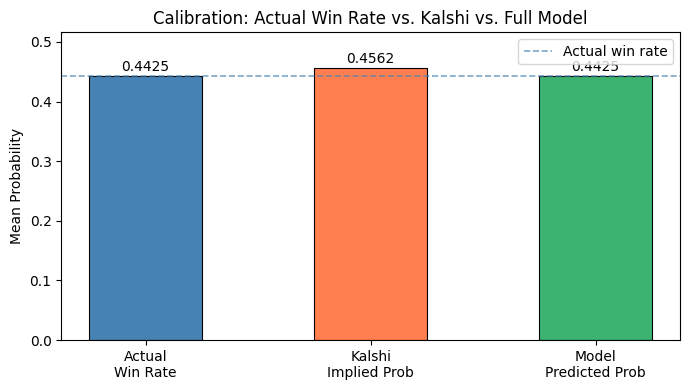

In [127]:
np.random.seed(42)

# Add actual game outcomes so we can compare both Kalshi and the model to ground truth
cal_df = mispricing_df.merge(
    games_df[['event_ticker', 'team1_won']], on='event_ticker', how='inner'
).dropna()

actual = cal_df['team1_won'].values          # 1 = team1 won, 0 = team1 lost
kalshi = cal_df['team1_implied_prob'].values  # Kalshi's pregame price for team1
model  = cal_df['model_prob_t1'].values       # our model's pregame prediction

# --- How far is each from the actual win rate? ---
print(f"Actual team1 win rate:      {actual.mean():.4f}")
print(f"Kalshi mean implied prob:   {kalshi.mean():.4f}  (gap: {kalshi.mean() - actual.mean():+.4f})")
print(f"Model mean predicted prob:  {model.mean():.4f}  (gap: {model.mean() - actual.mean():+.4f})")

# --- Permutation test: is Kalshi's mean different from the actual win rate? ---
# Same shuffle style as class homework
combined_k = np.concatenate([kalshi, actual])
n = len(kalshi)
obs_k = kalshi.mean() - actual.mean()

perm_diffs_k = []
for _ in range(5000):
    copy = combined_k.copy()
    np.random.shuffle(copy)
    perm_diffs_k.append(copy[:n].mean() - copy[n:].mean())

p_kalshi = np.mean(np.abs(perm_diffs_k) >= np.abs(obs_k))  # two-sided

# --- Permutation test: is the model's mean different from the actual win rate? ---
combined_m = np.concatenate([model, actual])
obs_m = model.mean() - actual.mean()

perm_diffs_m = []
for _ in range(10_000):
    copy = combined_m.copy()
    np.random.shuffle(copy)
    perm_diffs_m.append(copy[:n].mean() - copy[n:].mean())

p_model = np.mean(np.abs(perm_diffs_m) >= np.abs(obs_m))

print(f"\nPermutation p-value (Kalshi vs actual): {p_kalshi:.4f}")
print(f"Permutation p-value (Model vs actual):  {p_model:.4f}")

# --- Bar chart: who is closest to reality? ---
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Actual\nWin Rate', 'Kalshi\nImplied Prob', 'Model\nPredicted Prob']
values = [actual.mean(), kalshi.mean(), model.mean()]
colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8, width=0.5)
ax.axhline(actual.mean(), color='steelblue', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Actual win rate')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Mean Probability')
ax.set_title('Calibration: Actual Win Rate vs. Kalshi vs. Full Model')
ax.set_ylim(0, max(values) + 0.06)
ax.legend()
plt.tight_layout()
plt.show()
